In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import os
import random

from DCmatch import Match

from warnings import simplefilter
simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

In [4]:
folder = os.fsencode("seasons/bettingSeasons")
dataframes = []
for file in sorted(os.listdir(folder)):
    filename = os.fsdecode(file)
    if filename.endswith(".csv"):
        print(filename)
        df = pd.read_csv("seasons/bettingSeasons/" + filename)
        dataframes.append(df)

data = pd.concat(dataframes, axis=0)

1920-Copy1.csv
2021-Copy1.csv
2122-Copy1.csv
2223-Copy1.csv
2324-Copy1.csv
2425-Copy1.csv
E0.csv


In [6]:
data = data[[
    "Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR", "HS", "AS", "HST", "AST", 
    "B365H", "B365D", "B365A", "MaxH", "MaxD", "MaxA", "AvgH", "AvgD", "AvgA"
]]

In [8]:
data.describe()

,FTHG,FTAG,HS,AS,HST,AST,B365H,B365D,B365A,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA
count,2410.000000,2410.000000,2410.000000,2410.000000,2410.000000,2410.000000,2410.000000,2410.000000,2410.000000,2410.000000,2410.000000,2410.000000,2410.000000,2410.000000,2410.000000
mean,1.556432,1.320747,13.809544,11.642324,4.809959,4.107884,2.903838,4.256589,4.438257,3.112817,4.535075,5.010647,2.938527,4.287058,4.557996
std,1.326178,1.223314,5.688160,5.205678,2.598572,2.393601,2.083826,1.347750,3.766483,2.444435,1.575768,5.090810,2.137743,1.352043,4.106464
min,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.060000,2.800000,1.140000,1.090000,3.100000,1.170000,1.070000,2.970000,1.150000
25%,1.000000,0.000000,10.000000,8.000000,3.000000,2.000000,1.620000,3.500000,2.150000,1.700000,3.650000,2.250000,1.650000,3.490000,2.180000
50%,1.000000,1.000000,13.000000,11.000000,5.000000,4.000000,2.250000,3.800000,3.200000,2.380000,4.000000,3.310000,2.290000,3.820000,3.185000
75%,2.000000,2.000000,17.000000,15.000000,6.000000,5.000000,3.300000,4.500000,5.250000,3.470000,4.750000,5.600000,3.320000,4.540000,5.230000
max,9.000000,9.000000,36.000000,37.000000,16.000000,15.000000,19.000000,13.000000,29.000000,22.000000,17.000000,50.000000,18.090000,12.850000,37.570000


In [10]:
simpleData = data[["HomeTeam", "AwayTeam", "FTHG", "FTAG"]]
simpleData

,HomeTeam,AwayTeam,FTHG,FTAG
0,Liverpool,Norwich,4,1
1,West Ham,Man City,0,5
2,Bournemouth,Sheffield United,1,1
3,Burnley,Southampton,3,0
4,Crystal Palace,Everton,0,0
...,...,...,...,...
125,Crystal Palace,Man United,1,2
126,Aston Villa,Wolves,1,0
127,Nott'm Forest,Brighton,0,2
128,West Ham,Liverpool,0,2


In [12]:
uniqueTeams = data["HomeTeam"].unique()

In [14]:
teamsIndex = {}
for i in range(len(uniqueTeams)):
    teamsIndex[uniqueTeams[i]] = i
teamsIndex

{'Liverpool': 0,
 'West Ham': 1,
 'Bournemouth': 2,
 'Burnley': 3,
 'Crystal Palace': 4,
 'Watford': 5,
 'Tottenham': 6,
 'Leicester': 7,
 'Newcastle': 8,
 'Man United': 9,
 'Arsenal': 10,
 'Aston Villa': 11,
 'Brighton': 12,
 'Everton': 13,
 'Norwich': 14,
 'Southampton': 15,
 'Man City': 16,
 'Sheffield United': 17,
 'Chelsea': 18,
 'Wolves': 19,
 'Fulham': 20,
 'West Brom': 21,
 'Leeds': 22,
 'Brentford': 23,
 "Nott'm Forest": 24,
 'Luton': 25,
 'Ipswich': 26,
 'Sunderland': 27}

In [16]:
from scipy.optimize import minimize
def phi(t):
    return np.exp(-0.0065*t)

def logLikelihood(parameters, data):
    numTeams = int((len(parameters) - 2) // 2)
    
    attackStrengths = np.array(parameters[0:numTeams])
    defenceStrengths = np.array(parameters[numTeams:numTeams*2])
    
    homeAdv = parameters[-2]
    rho = parameters[-1]
    t = data.index[-1]
    ll = 0

    for tk, row in data.iterrows():
        i = teamsIndex.get(row["HomeTeam"])
        j = teamsIndex.get(row["AwayTeam"])
        x = int(row["FTHG"])
        y = int(row["FTAG"])

        lamd = attackStrengths[i] * defenceStrengths[j] * homeAdv
        mu = attackStrengths[j] * defenceStrengths[i]

        ll += (np.log(Match.tauFunc(lamd, mu, rho, x, y) + 1e-7) - lamd + x*np.log(lamd) - mu + y*np.log(mu)) * phi(t - tk)
    
    return -ll

In [17]:
from scipy.optimize import minimize
np.random.seed(1008)
def getNewEstimates(results: pd.DataFrame):
    rng = np.random.default_rng(123)
    init_att = rng.uniform(0.8, 1.3, size=len(uniqueTeams))
    init_def = rng.uniform(0.8, 1.3, size=len(uniqueTeams))
    init_home = 1.1
    init_rho = 0.0

    init = np.concatenate([init_att, init_def, [init_home, init_rho]])

    bounds = [(1e-6, None)] * (2*len(uniqueTeams)) + [(1e-6, None), (-0.99, 0.99)]

    result = minimize(
        logLikelihood,
        init,
        args=(results,),
        bounds=bounds,
        options={'maxiter': 10000, 'disp': True},
    )
    return result.x

In [20]:
import csv
len(data["HomeTeam"])

2410

In [22]:
currentEstimates = getNewEstimates(simpleData)

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           58     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  8.28926D+03    |proj g|=  1.49612D+03

At iterate    1    f=  7.89813D+03    |proj g|=  2.28787D+02

At iterate    2    f=  7.78169D+03    |proj g|=  1.97014D+02

At iterate    3    f=  7.32370D+03    |proj g|=  1.20524D+02

At iterate    4    f=  7.27737D+03    |proj g|=  1.28093D+02

At iterate    5    f=  7.26069D+03    |proj g|=  5.52634D+01

At iterate    6    f=  7.24066D+03    |proj g|=  2.35818D+01

At iterate    7    f=  7.23390D+03    |proj g|=  1.94827D+01

At iterate    8    f=  7.23006D+03    |proj g|=  1.54365D+01

At iterate    9    f=  7.22797D+03    |proj g|=  2.63924D+01

At iterate   10    f=  7.22599D+03    |proj g|=  2.15275D+01

At iterate   11    f=  7.22525D+03    |proj g|=  2.00826D+01

At iterate   12    f=  7.22496D+03    |proj g|=  1.30832D+01

At iterate   13    f=  7.2

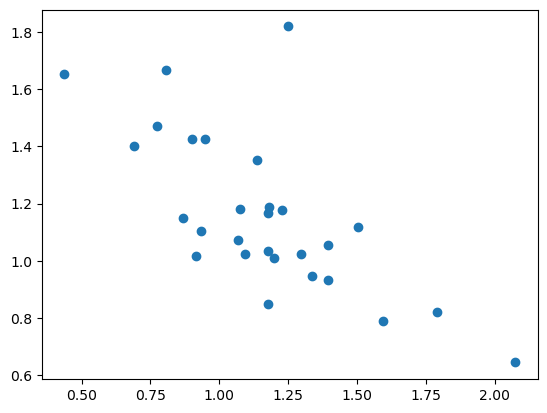

In [24]:
teamsLookup = {v: k for k, v in teamsIndex.items()}

fig, ax = plt.subplots()
ax.scatter(currentEstimates[0:28], currentEstimates[28:56])

In [56]:
home = "Man Ci"
away = "West Ham"
match = Match(currentEstimates[teamsIndex.get(home)], currentEstimates[teamsIndex.get(home) + 28], currentEstimates[teamsIndex.get(away)], currentEstimates[teamsIndex.get(away) + 28], currentEstimates[-2], currentEstimates[-1], 8)

In [58]:
1 / np.array(match.getOutcomeProbs())

array([1.86692946, 4.42259692, 4.19727834])

In [14]:
estimatesAtTimeT = []
for i in range(200, len(data["HomeTeam"]), 10):
    estimatesAtTimeT.append(getNewEstimates(simpleData.head(n=i)))

with open("estimatesOvernight.csv", "w+") as my_csv:
    csvWriter = csv.writer(my_csv,delimiter=',')
    csvWriter.writerows(estimatesAtTimeT)

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           58     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  2.12115D+02    |proj g|=  2.24056D+01

At iterate    1    f=  2.03894D+02    |proj g|=  6.71192D+00

At iterate    2    f=  1.98120D+02    |proj g|=  5.38861D+00

At iterate    3    f=  1.84575D+02    |proj g|=  6.92619D+00

At iterate    4    f=  1.84068D+02    |proj g|=  1.07320D+00

At iterate    5    f=  1.84008D+02    |proj g|=  8.50798D-01

At iterate    6    f=  1.83886D+02    |proj g|=  4.47267D-01

At iterate    7    f=  1.83882D+02    |proj g|=  4.96377D-01

At iterate    8    f=  1.83878D+02    |proj g|=  8.63253D-02

At iterate    9    f=  1.83878D+02    |proj g|=  4.93145D-02

At iterate   10    f=  1.83878D+02    |proj g|=  2.83478D-02

At iterate   11    f=  1.83877D+02    |proj g|=  1.00698D-02

At iterate   12    f=  1.83877D+02    |proj g|=  2.07962D-02

At iterate   13    f=  1.8

/var/folders/c8/mqhljcz12rld881pkd18bzxc0000gn/T/ipykernel_4393/2450435370.py:25: RuntimeWarning: invalid value encountered in log
  ll += (np.log(Match.tauFunc(lamd, mu, rho, x, y) + 1e-7) - lamd + x*np.log(lamd) - mu + y*np.log(mu)) * phi(t - tk)



At iterate    3    f=  2.31089D+02    |proj g|=  3.13194D+00



 Bad direction in the line search;
   refresh the lbfgs memory and restart the iteration.

 Line search cannot locate an adequate point after MAXLS
  function and gradient evaluations.
  Previous x, f and g restored.
 Possible causes: 1 error in function or gradient evaluation;
                  2 rounding error dominate computation.



           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
   58      4     46     33     0    15   3.132D+00   2.311D+02
  F =   231.08905787012850     

ABNORMAL_TERMINATION_IN_LNSRCH                              
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           58     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  2.66427D+02    |proj g|=  3.49168D+01

At iterate    1    f=  2.55991D+02    |proj g|=  7.99797D+00

At iterate    2    f=  2.48140D+02    |proj g|=  6.55541D+00

At iterate    3    f=  2.30431D+02    |proj g|=  3.22631D+01

At iter

In [16]:
len(estimatesAtTimeT[0])

58

In [17]:
strengthsOverTime = [[row[i] for row in estimatesAtTimeT] for i in range(len(estimatesAtTimeT[0]))]

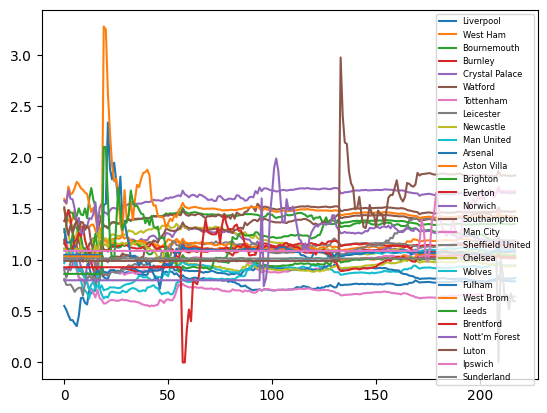

In [216]:
teamsLookup = {v: k for k, v in teamsIndex.items()}

fig, ax = plt.subplots()
for i in range(28):
    ax.plot(strengthsOverTime[28+i], label=f"{teamsLookup.get(i)}")

ax.legend(prop={'size': 6})

In [21]:
len(strengthsOverTime[0])

218

In [187]:
teamStrengths = [[] for i in range(58)]

for i in range(len(simpleData["AwayTeam"])):
    if i < 200:
        for j in range(58):
            teamStrengths[j].append(0)
    else:
        for j in range(58):
            teamStrengths[j].append(strengthsOverTime[j][(i-200) // 10])

In [188]:
len(simpleData["HomeTeam"])

2380

In [189]:
len(teamStrengths[0])

2380

In [190]:
data.describe()

/Users/jamesrestell/Library/Python/3.9/lib/python/site-packages/pandas/core/nanops.py:1010: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/jamesrestell/Library/Python/3.9/lib/python/site-packages/pandas/core/nanops.py:1010: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,FTHG,FTAG,HS,AS,HST,AST,B365H,B365D,B365A,MaxH,...,attackA,defenceA,rho,homeAdv,homeProb,drawProb,awayProb,FairHomeOdds,FairDrawOdds,FairAwayOdds
count,2380.000000,2380.000000,2380.000000,2380.000000,2380.000000,2380.000000,2380.000000,2380.000000,2380.000000,2380.000000,...,2380.000000,2380.000000,2380.000000,2380.000000,2380.000000,2380.000000,2380.000000,2380.000000,2380.000000,2380.000000
mean,1.554622,1.320168,13.800000,11.664286,4.809664,4.111765,2.907231,4.260996,4.444929,3.116929,...,1.086121,0.977646,-0.024683,1.095824,0.392822,0.301726,0.305452,inf,4.263207,inf
std,1.326786,1.226037,5.692956,5.208182,2.600706,2.397655,2.090992,1.353086,3.780520,2.452117,...,0.482506,0.369647,0.032768,0.335788,0.219603,0.217489,0.194562,NaN,2.208070,NaN
min,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.060000,2.800000,1.140000,1.090000,...,0.000000,0.000000,-0.157712,0.000000,0.000000,0.026184,0.000000,1.033709,1.000000,1.085158
25%,1.000000,0.000000,10.000000,8.000000,3.000000,2.000000,1.620000,3.500000,2.150000,1.700000,...,0.872700,0.889283,-0.038405,1.160322,0.246198,0.217401,0.162045,1.827475,3.581635,2.323840
50%,1.000000,1.000000,13.000000,11.000000,5.000000,4.000000,2.250000,3.800000,3.200000,2.380000,...,1.088046,1.044461,-0.015536,1.179341,0.387137,0.247188,0.294542,2.583066,4.045509,3.395106
75%,2.000000,2.000000,17.000000,15.000000,6.000000,5.000000,3.300000,4.500000,5.250000,3.480000,...,1.365460,1.156759,0.000000,1.193839,0.547203,0.279202,0.430322,4.061773,4.599788,6.171125
max,9.000000,9.000000,36.000000,37.000000,16.000000,15.000000,19.000000,13.000000,29.000000,22.000000,...,2.446876,2.974163,0.043453,1.404289,0.967390,1.000000,0.921525,inf,38.191574,inf


In [191]:
attack = teamStrengths[0:28]
defence = teamStrengths[28:56]
homeAdvantage = teamStrengths[-2]
rho = teamStrengths[-1]

In [192]:
len(homeAdvantage)

2380

In [193]:
home_idx = data["HomeTeam"].map(teamsIndex).to_numpy()
away_idx = data["AwayTeam"].map(teamsIndex).to_numpy()

In [194]:
print(attack[away_idx[900]][910])

0.8847161072823861


In [195]:
t = np.arange(len(data["HomeTeam"]))

In [196]:
t

array([   0,    1,    2, ..., 2377, 2378, 2379])

In [197]:
homeAttacks = []
homeDefences = []
awayAttacks = []
awayDefences = []

for i in range(len(data["HomeTeam"])):
    homeAttacks.append(attack[home_idx[i]][i])
    homeDefences.append(defence[home_idx[i]][i])
    awayAttacks.append(attack[away_idx[i]][i])
    awayDefences.append(defence[away_idx[i]][i])

homeProbs = []
drawProbs = []
awayProbs = []

for i in range(len(data["HomeTeam"])):
    thisMatch = Match(homeAttacks[i], homeDefences[i], awayAttacks[i], awayDefences[i], homeAdvantage[i], rho[i], 8)
    outcomes = thisMatch.getOutcomeProbs()
    homeProbs.append(outcomes[0])
    drawProbs.append(outcomes[1])
    awayProbs.append(outcomes[2])



data["attackH"]  = homeAttacks
data["defenceH"] = homeDefences
data["attackA"]  = awayAttacks
data["defenceA"] = awayDefences
data["rho"] = rho
data["homeAdv"] = homeAdvantage
data["homeProb"] = homeProbs
data["drawProb"] = drawProbs
data["awayProb"] = awayProbs
data["FairHomeOdds"] = 1 / data["homeProb"]
data["FairDrawOdds"] = 1 / data["drawProb"]
data["FairAwayOdds"] = 1 / data["awayProb"]

In [198]:
data.tail()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,AST,...,attackA,defenceA,rho,homeAdv,homeProb,drawProb,awayProb,FairHomeOdds,FairDrawOdds,FairAwayOdds
95,01/11/2025,Tottenham,Chelsea,0,1,A,3,15,1,9,...,1.394149,0.940286,0.004966,1.176475,0.407536,0.232125,0.360339,2.453769,4.308031,2.775165
96,01/11/2025,Liverpool,Aston Villa,2,0,H,16,10,4,3,...,1.196041,1.015676,0.004966,1.176475,0.638734,0.197506,0.163760,1.565597,5.063140,6.106490
97,02/11/2025,West Ham,Newcastle,3,1,H,15,12,9,4,...,1.388267,1.053781,0.004966,1.176475,0.356811,0.234933,0.408256,2.802602,4.256537,2.449444
98,02/11/2025,Man City,Bournemouth,3,1,H,15,8,8,5,...,1.069273,1.175001,0.004966,1.176475,0.816666,0.120382,0.062952,1.224491,8.306867,15.885201
99,03/11/2025,Sunderland,Everton,1,1,D,17,8,3,2,...,0.911645,1.020615,0.004966,1.176475,0.551004,0.291733,0.157263,1.814869,3.427788,6.358792


In [199]:
bettingFrame = data.tail(n=2180)
bettingFrame["HomeWin"] = np.where(bettingFrame["FTR"] == "H", 1, 0)
bettingFrame["Draw"] = np.where(bettingFrame["FTR"] == "D", 1, 0)
bettingFrame["AwayWin"] = np.where(bettingFrame["FTR"] == "A", 1, 0)
bettingFrame.head()

/var/folders/c8/mqhljcz12rld881pkd18bzxc0000gn/T/ipykernel_4393/3958715411.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bettingFrame["HomeWin"] = np.where(bettingFrame["FTR"] == "H", 1, 0)
/var/folders/c8/mqhljcz12rld881pkd18bzxc0000gn/T/ipykernel_4393/3958715411.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bettingFrame["Draw"] = np.where(bettingFrame["FTR"] == "D", 1, 0)
/var/folders/c8/mqhljcz12rld881pkd18bzxc0000gn/T/ipykernel_4393/3958715411.py:4: SettingWithCopyWarning: 
A value is trying

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,AST,...,homeAdv,homeProb,drawProb,awayProb,FairHomeOdds,FairDrawOdds,FairAwayOdds,HomeWin,Draw,AwayWin
200,01/01/2020,Burnley,Aston Villa,1,2,A,20,11,1,6,...,1.095947,0.401036,0.267411,0.331553,2.493541,3.739565,3.016109,0,0,1
201,01/01/2020,Newcastle,Leicester,0,3,A,5,17,2,10,...,1.095947,0.132853,0.201389,0.665758,7.527110,4.965526,1.502047,0,0,1
202,01/01/2020,Southampton,Tottenham,1,0,H,12,11,3,5,...,1.095947,0.237765,0.209617,0.552617,4.205827,4.770599,1.809570,1,0,0
203,01/01/2020,Watford,Wolves,2,1,H,9,16,3,4,...,1.095947,0.198164,0.284994,0.516842,5.046331,3.508843,1.934827,1,0,0
204,01/01/2020,Man City,Everton,2,1,H,16,7,7,2,...,1.095947,0.742369,0.153005,0.104625,1.347038,6.535719,9.557922,1,0,0


In [200]:
bettingFrame["HomeBet"] = np.where(bettingFrame['MaxH'] > bettingFrame["FairHomeOdds"], 1, 0)
bettingFrame["AwayBet"] = np.where(bettingFrame['MaxA'] > bettingFrame["FairAwayOdds"], 1, 0)
bettingFrame["DrawBet"] = np.where(bettingFrame['MaxD'] > bettingFrame["FairDrawOdds"], 1, 0)

/var/folders/c8/mqhljcz12rld881pkd18bzxc0000gn/T/ipykernel_4393/1965453912.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bettingFrame["HomeBet"] = np.where(bettingFrame['MaxH'] > bettingFrame["FairHomeOdds"], 1, 0)
/var/folders/c8/mqhljcz12rld881pkd18bzxc0000gn/T/ipykernel_4393/1965453912.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bettingFrame["AwayBet"] = np.where(bettingFrame['MaxA'] > bettingFrame["FairAwayOdds"], 1, 0)
/var/folders/c8/mqhljcz12rld881pkd18bzxc0000gn/T/ipykernel_4393/196545

In [201]:
bettingFrame = bettingFrame[[
    "Date", "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR",
    "B365H", "B365D", "B365A", "MaxH", "MaxD", "MaxA", 'attackH', 'defenceH', 'attackA', 'defenceA', 'rho',
    'homeAdv', 'homeProb', 'drawProb', 'awayProb', 'FairHomeOdds',
    'FairDrawOdds', 'FairAwayOdds', 'HomeWin', 'Draw', 'AwayWin', 'HomeBet',
    "DrawBet", 'AwayBet'
]]

In [202]:
bettingFrame.tail()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,B365H,B365D,B365A,MaxH,...,awayProb,FairHomeOdds,FairDrawOdds,FairAwayOdds,HomeWin,Draw,AwayWin,HomeBet,DrawBet,AwayBet
95,01/11/2025,Tottenham,Chelsea,0,1,A,2.70,3.50,2.50,2.80,...,0.360339,2.453769,4.308031,2.775165,0,0,1,1,0,0
96,01/11/2025,Liverpool,Aston Villa,2,0,H,1.65,4.33,4.50,1.67,...,0.163760,1.565597,5.063140,6.106490,1,0,0,1,0,0
97,02/11/2025,West Ham,Newcastle,3,1,H,5.25,4.00,1.62,5.50,...,0.408256,2.802602,4.256537,2.449444,1,0,0,1,1,0
98,02/11/2025,Man City,Bournemouth,3,1,H,1.50,4.75,5.75,1.50,...,0.062952,1.224491,8.306867,15.885201,1,0,0,1,0,0
99,03/11/2025,Sunderland,Everton,1,1,D,2.70,3.20,2.70,2.80,...,0.157263,1.814869,3.427788,6.358792,0,1,0,1,0,0


In [203]:
bettingFrame["Profit"] = bettingFrame["HomeWin"] * bettingFrame["HomeBet"] * bettingFrame["MaxH"] + bettingFrame["AwayWin"] * bettingFrame["AwayBet"] * bettingFrame["MaxA"] - (bettingFrame["HomeBet"] + bettingFrame["AwayBet"])

In [204]:
bettingFrame.head()

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,B365H,B365D,B365A,MaxH,...,FairHomeOdds,FairDrawOdds,FairAwayOdds,HomeWin,Draw,AwayWin,HomeBet,DrawBet,AwayBet,Profit
200,01/01/2020,Burnley,Aston Villa,1,2,A,1.75,3.8,4.33,1.85,...,2.493541,3.739565,3.016109,0,0,1,0,1,1,3.60
201,01/01/2020,Newcastle,Leicester,0,3,A,5.00,3.8,1.66,5.85,...,7.527110,4.965526,1.502047,0,0,1,0,0,1,0.71
202,01/01/2020,Southampton,Tottenham,1,0,H,3.30,3.5,2.10,3.51,...,4.205827,4.770599,1.809570,1,0,0,0,0,1,-1.00
203,01/01/2020,Watford,Wolves,2,1,H,3.00,3.4,2.30,3.30,...,5.046331,3.508843,1.934827,1,0,0,0,0,1,-1.00
204,01/01/2020,Man City,Everton,2,1,H,1.25,6.5,10.00,1.30,...,1.347038,6.535719,9.557922,1,0,0,0,1,1,-1.00


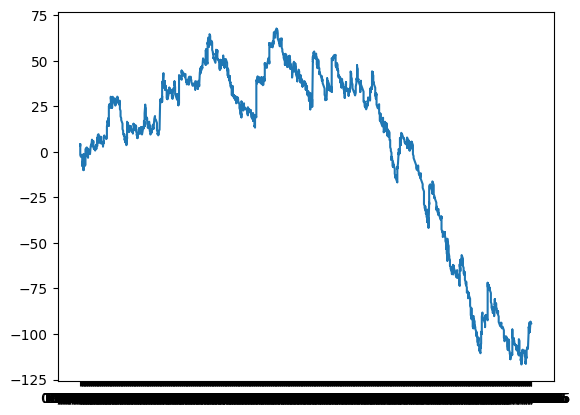

In [205]:
fig, ax = plt.subplots()
ax.plot(bettingFrame["Date"], bettingFrame["Profit"].cumsum())

In [206]:
bettingFrame.HomeBet.sum() + bettingFrame.DrawBet.sum() + bettingFrame.AwayBet.sum()

3243

In [207]:
bettingFrame["Profit"].sum()

-94.17000000000002

In [209]:
-94.17 / 3243

-0.029037927844588345

In [210]:
cleanProfits = [x for x in bettingFrame.Profit if x!=0]

In [211]:
np.var(cleanProfits)

3.605239165782313

In [212]:
np.mean(cleanProfits)

-0.04484285714285715

In [213]:
import csv


with open("profitsMLE.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(cleanProfits)